In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

valid_input_dir = "/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR"
valid_hr_path = "/kaggle/working/valid_hr"
valid_lr_path = "/kaggle/working/valid_lr"

os.makedirs(valid_hr_path, exist_ok=True)
os.makedirs(valid_lr_path, exist_ok=True)

for img_name in tqdm(os.listdir(valid_input_dir), desc="Validation Hazırlanıyor"):
    img_path = os.path.join(valid_input_dir, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        hr = cv2.resize(img, (1920, 1080), interpolation=cv2.INTER_CUBIC)
        lr = cv2.resize(hr, (640, 360), interpolation=cv2.INTER_CUBIC)
        cv2.imwrite(os.path.join(valid_hr_path, img_name), hr)
        cv2.imwrite(os.path.join(valid_lr_path, img_name), lr)

Validation Hazırlanıyor: 100%|██████████| 100/100 [00:25<00:00,  3.86it/s]


In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

class ESPCN(nn.Module):
    def __init__(self, upscale_factor=3):
        super(ESPCN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 3 * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.conv1(x))
        x = self.tanh(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        return x

# 2. AYARLAR VE YÜKLEME
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ESPCN(upscale_factor=3).to(device)

model_path = "/kaggle/input/datasets/haliten/espcn-360p-to-1080p/espcn_360p_to_1080p.pth" 

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("The model was successfully loaded from the Input folder!")

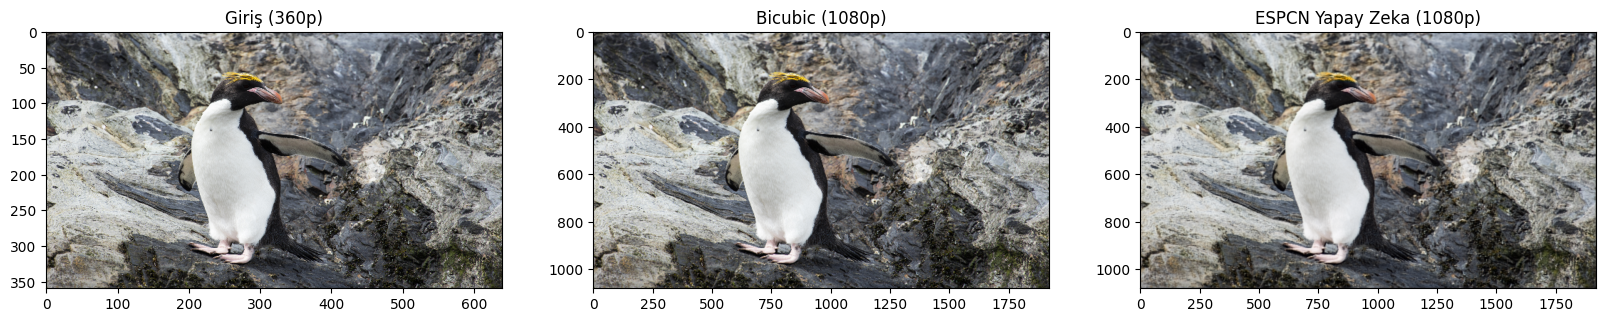

In [ ]:
def test_and_visualize(image_path):
    hr_orig = cv2.imread(image_path)
    hr_orig = cv2.resize(hr_orig, (1920, 1080), interpolation=cv2.INTER_CUBIC)
    
    lr_input = cv2.resize(hr_orig, (640, 360), interpolation=cv2.INTER_CUBIC)
    
    img_pil = Image.fromarray(cv2.cvtColor(lr_input, cv2.COLOR_BGR2RGB))
    input_tensor = transforms.ToTensor()(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
    
    sr_output = output.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    sr_output = np.clip(sr_output * 255, 0, 255).astype(np.uint8)
    sr_output = cv2.cvtColor(sr_output, cv2.COLOR_RGB2BGR)

    bicubic_upscale = cv2.resize(lr_input, (1920, 1080), interpolation=cv2.INTER_CUBIC)

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(lr_input, cv2.COLOR_BGR2RGB)); plt.title("input (360p)")
    plt.subplot(1, 3, 2); plt.imshow(cv2.cvtColor(bicubic_upscale, cv2.COLOR_BGR2RGB)); plt.title("Bicubic (1080p)")
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(sr_output, cv2.COLOR_BGR2RGB)); plt.title("ESPCN AI (1080p)")
    plt.show()

test_and_visualize("/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0801.png")

In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import math

def calculate_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    return 20 * math.log10(255.0 / math.sqrt(mse))

valid_hr_dir = "/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR"
psnr_values = []

valid_images = sorted(os.listdir(valid_hr_dir))[:10]

for img_name in valid_images:
    hr_img = cv2.imread(os.path.join(valid_hr_dir, img_name))
    hr_img = cv2.resize(hr_img, (1920, 1080), interpolation=cv2.INTER_CUBIC)
    
    lr_img_cv = cv2.resize(hr_img, (640, 360), interpolation=cv2.INTER_CUBIC)
    lr_img_pil = Image.fromarray(cv2.cvtColor(lr_img_cv, cv2.COLOR_BGR2RGB))
    
    input_tensor = transforms.ToTensor()(lr_img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    
    sr_img = output.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    sr_img = np.clip(sr_img * 255, 0, 255).astype(np.uint8)
    sr_img = cv2.cvtColor(sr_img, cv2.COLOR_RGB2BGR)
    
    current_psnr = calculate_psnr(hr_img, sr_img)
    psnr_values.append(current_psnr)
    print(f"Resim {img_name} -> PSNR: {current_psnr:.2f} dB")

print(f"\n Avarage Validation PSNR: {np.mean(psnr_values):.2f} dB")